# How does the sd of an SDT with normal noise increase with sensitivity

if the generating model is Gumble min?

## Introduction

In signal detection theory (SDT), the standard assumption is that the noise and signal distributions are Gaussian. In the unequal variance SDT (UVSD) model, the signal distribution is allowed to have a different standard deviation ($\sigma$) than the noise distribution. Empirically, $\sigma > 1$ is commonly observed and in some cases it tends to increase with sensitivity. Recent studies have suggested that a Gumble-min distribution might be a better model for the data. Here we investigate what happens when data are generated from a Gumbel-min model and then fit with a normal UVSD model.

## Generating ROC data from a Gumbel minimum model

We first define the CDF for the Gumbel minimum distribution and simulate ROC curves by varying the location parameter (sensitivity) of the signal distribution across several criterion values.

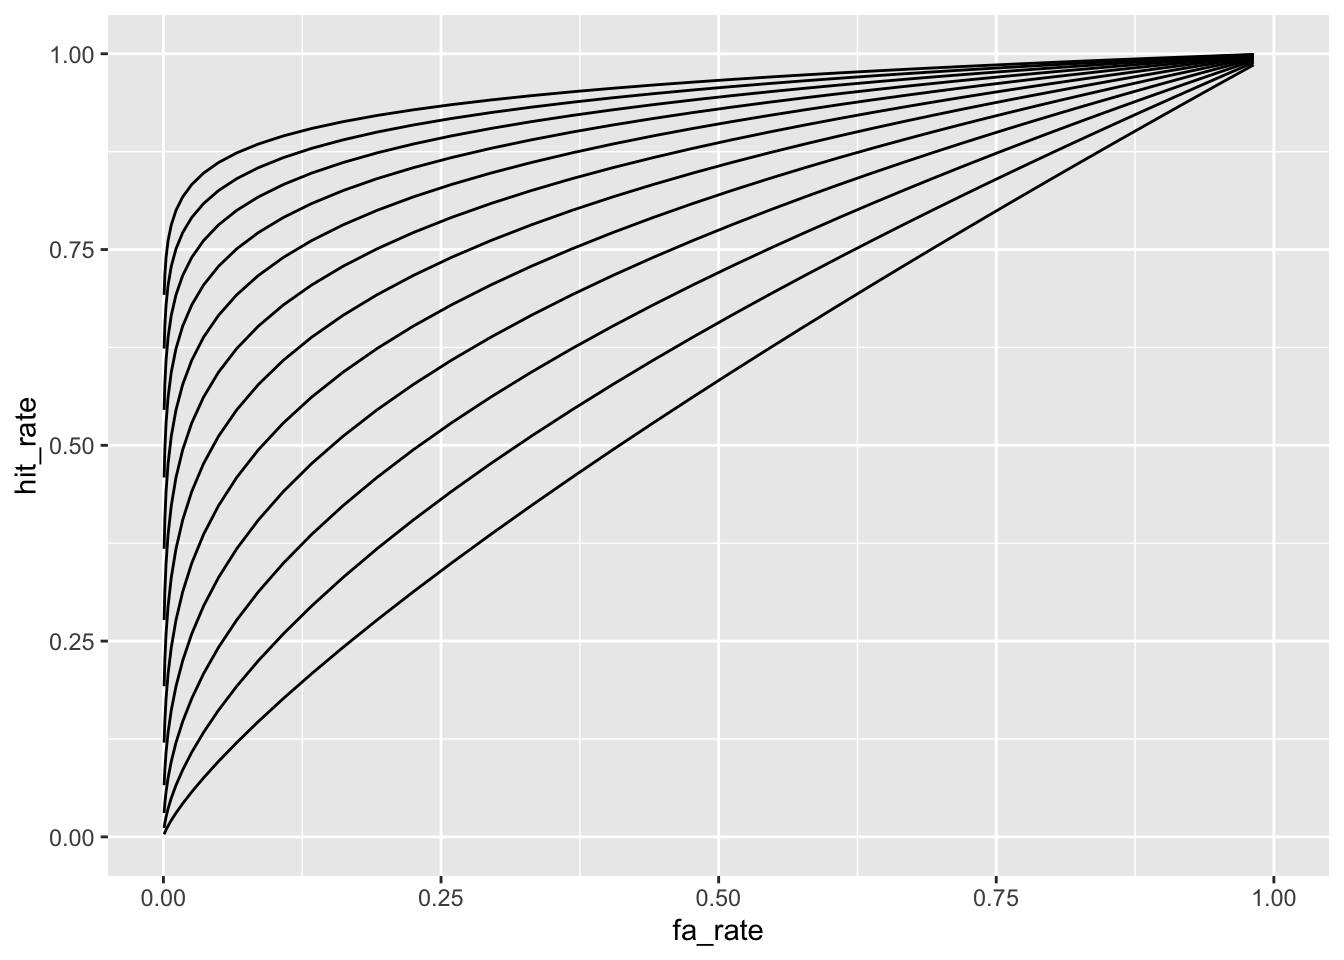

In [ ]:
library(ggplot2)
pgumbelmin <- function(x, location = 0, scale = 1) {
  z <- (x - location)/scale
  1-exp(-exp(z))
}

sim_roc <- function(d_signal, crits) {
  false_alarms <- 1 - pgumbelmin(crits)
  hits <- lapply(d_signal, \(d) 1 - pgumbelmin(crits, location = d))
  hits <- unlist(hits)
  data.frame(cond = rep(d_signal, each = length(crits)), hit_rate = hits, fa_rate = false_alarms)
}

dat <- sim_roc(d_signal = seq(0.25, 3, 0.25), crits = seq(-4, 2, 0.1))

ggplot(dat, aes(fa_rate, hit_rate, group = as.factor(cond))) +
  geom_line() +
  coord_cartesian(xlim = c(0,1), ylim = c(0,1))


## Fitting a normal UVSD model to the Gumbel-min data

We now fit an unequal variance signal detection model assuming normally distributed noise ($\sigma_{noise} = 1$) and signal ($\sigma_{signal}$ free) to the Gumbel-min ROC data. For each sensitivity condition, we estimate $d'$ and $\sigma$ by minimizing the squared difference between observed and predicted hit rates.

     cond     d_est sigma_est
0.25 0.25 0.2303595  1.077382
0.5  0.50 0.4803825  1.164386
0.75 0.75 0.7525590  1.261952
1    1.00 1.0491669  1.370073
1.25 1.25 1.3717829  1.487399
1.5  1.50 1.7211676  1.611856
1.75 1.75 2.0974614  1.741505
2    2.00 2.5003294  1.874835
2.25 2.25 2.9290051  2.010679
2.5  2.50 3.3823358  2.148088
2.75 2.75 3.8588581  2.286255
3    3.00 4.3568930  2.424489

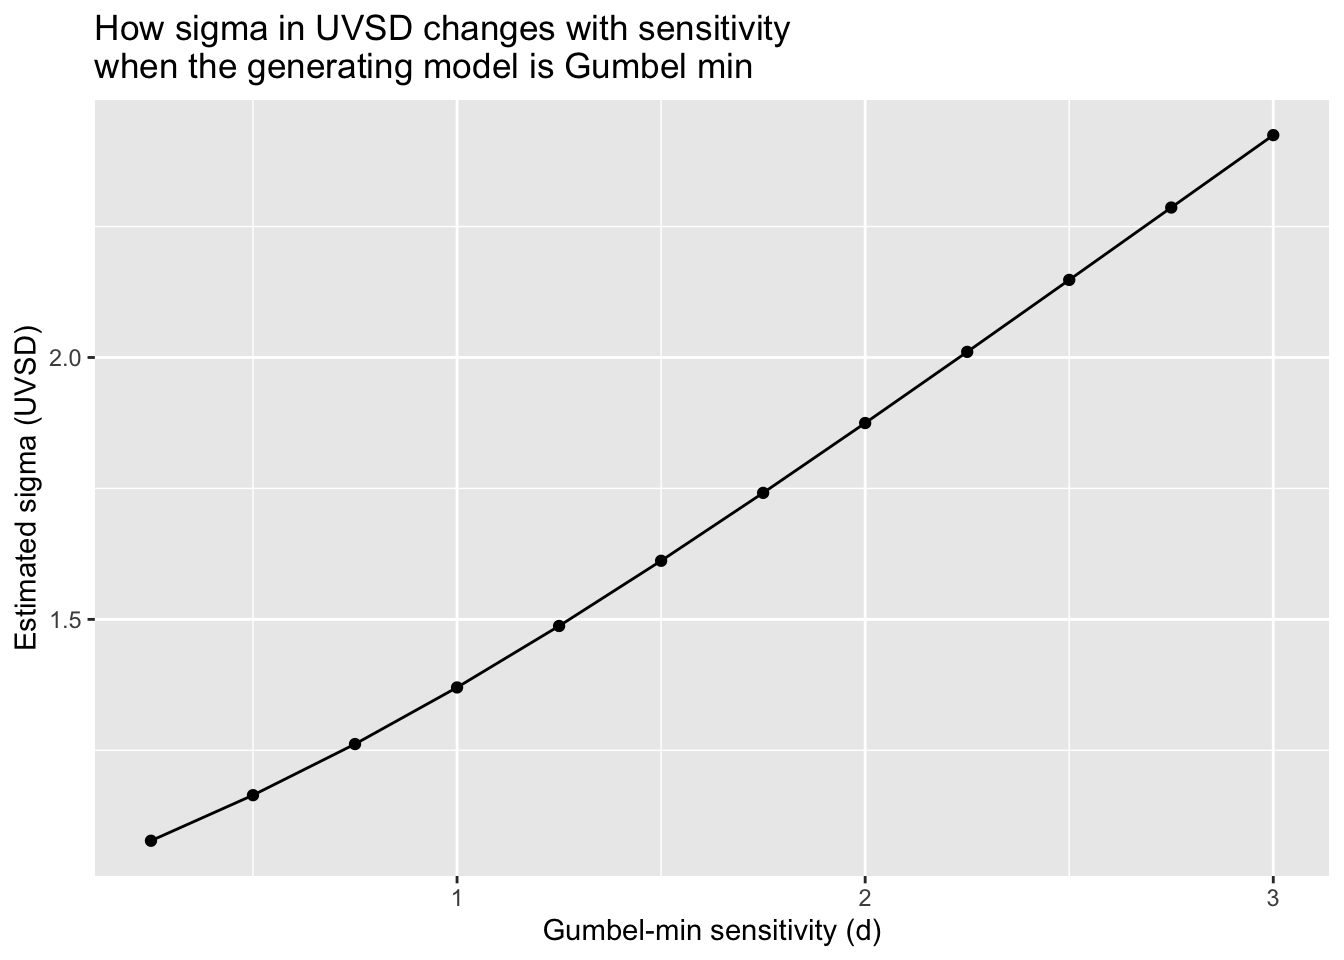

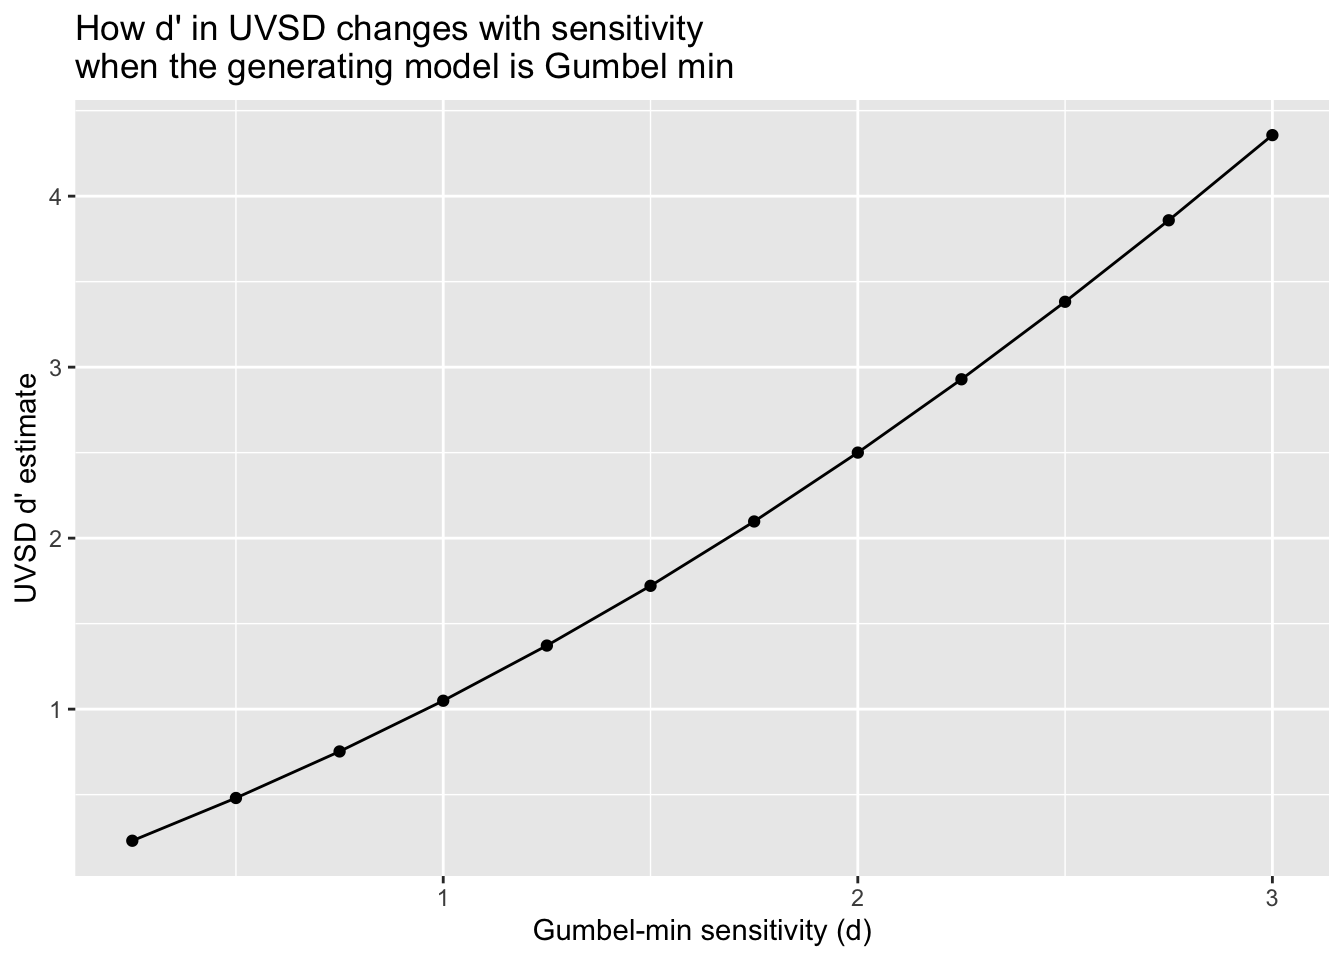

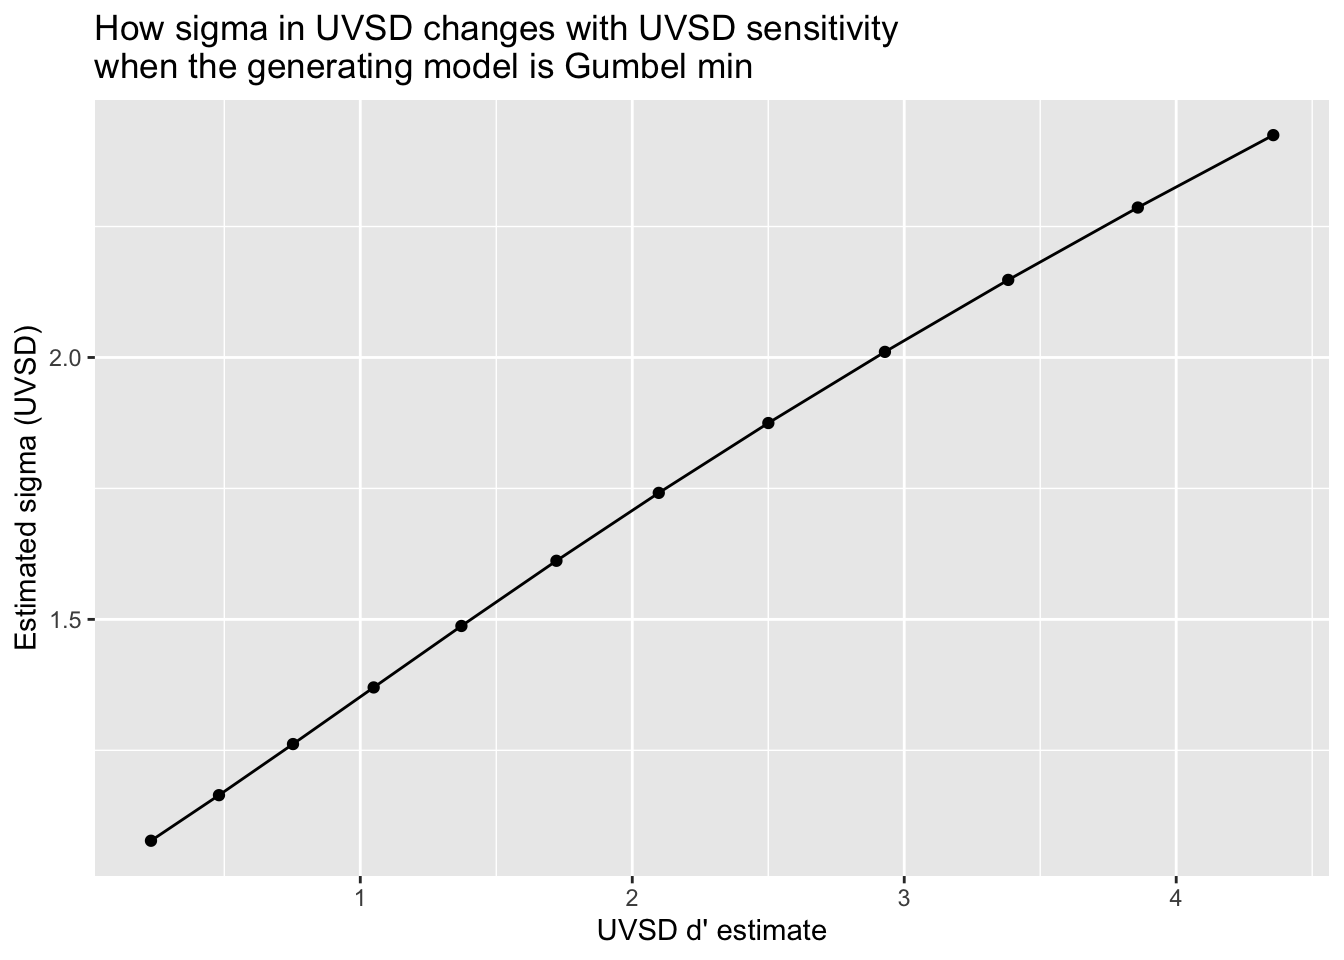

In [ ]:
fit_uvsd <- function(hit_rate, fa_rate) {
  # Given FA rate under normal noise: FA = 1 - Phi(c) => c = -qnorm(fa_rate)
  # Under UVSD: Hit = Phi((d - c) / sigma)
  obj <- function(par) {
    d <- par[1]
    sigma <- par[2]
    c_val <- -qnorm(fa_rate)
    pred_hit <- pnorm((d - c_val) / sigma)
    sum((hit_rate - pred_hit)^2)
  }
  opt <- optim(c(1, 1), obj, method = "L-BFGS-B",
               lower = c(0.01, 0.01), upper = c(10, 10))
  data.frame(d = opt$par[1], sigma = opt$par[2])
}

results <- do.call(rbind, lapply(split(dat, dat$cond), function(df) {
  fit <- fit_uvsd(df$hit_rate, df$fa_rate)
  data.frame(cond = df$cond[1], d_est = fit$d, sigma_est = fit$sigma)
}))

results


## Comparing ROC predictions: UVSD vs Gumbel-min

To assess the quality of the UVSD approximation, we overlay the predicted ROC curves from the fitted UVSD model on top of the true Gumbel-min ROC data.

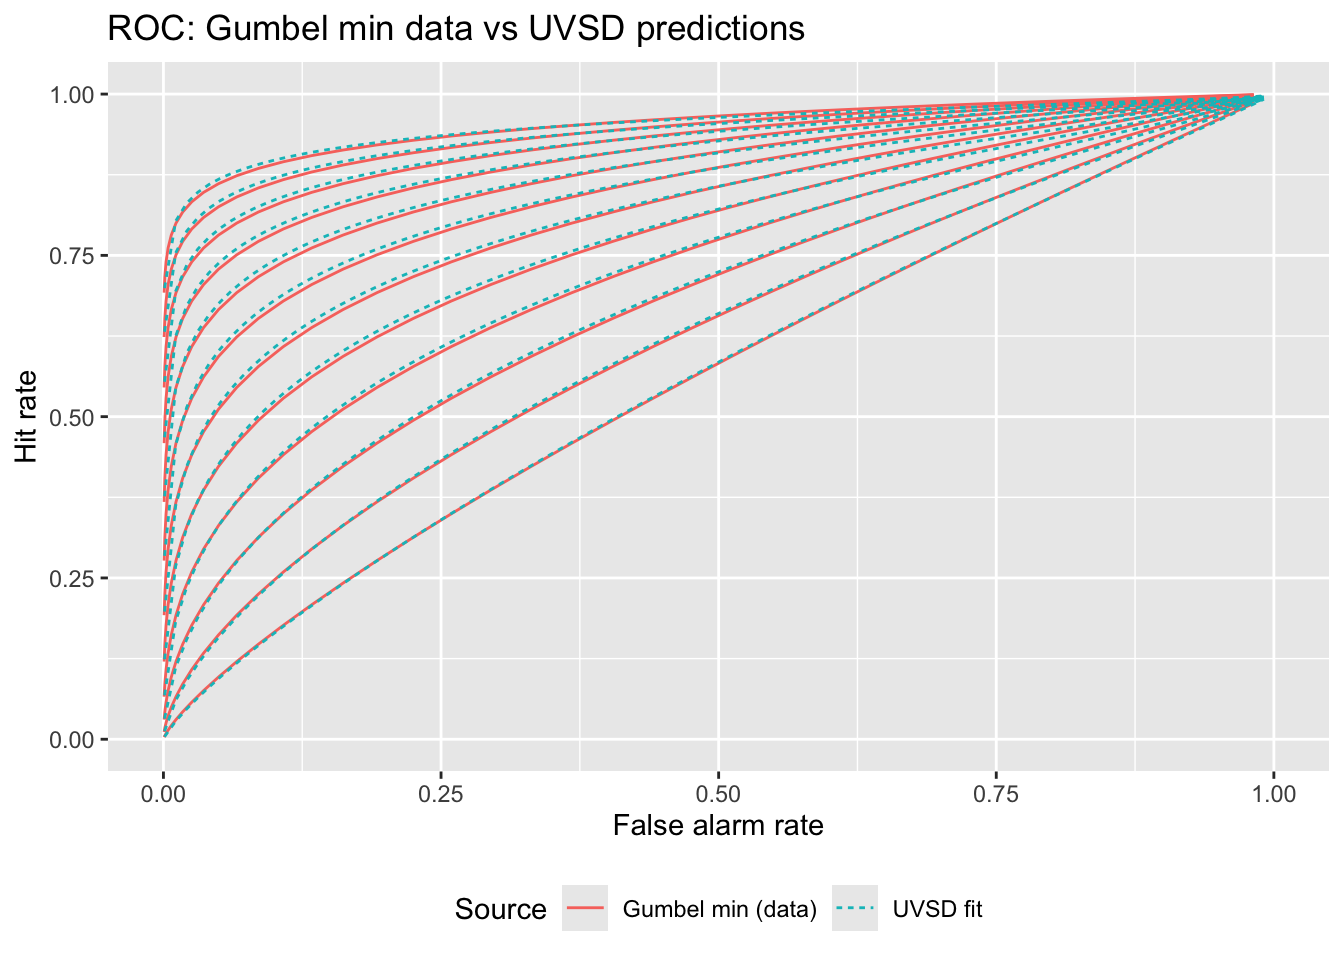

In [ ]:
# Generate UVSD predicted ROC curves from the fitted parameters
fa_seq <- seq(0.001, 0.999, 0.01)
uvsd_pred <- do.call(rbind, lapply(seq_len(nrow(results)), function(i) {
  d <- results$d_est[i]
  sigma <- results$sigma_est[i]
  c_val <- -qnorm(fa_seq)
  pred_hit <- pnorm((d - c_val) / sigma)
  data.frame(cond = results$cond[i], fa_rate = fa_seq, hit_rate = pred_hit,
             source = "UVSD fit")
}))

dat$source <- "Gumbel min (data)"
combined <- rbind(dat[, c("cond", "fa_rate", "hit_rate", "source")], uvsd_pred)

ggplot(combined, aes(fa_rate, hit_rate, color = source, group = interaction(cond, source))) +
  geom_line(aes(linetype = source)) +
  # facet_wrap(~ cond, labeller = label_both) +
  coord_cartesian(xlim = c(0, 1), ylim = c(0, 1)) +
  labs(x = "False alarm rate", y = "Hit rate",
       title = "ROC: Gumbel min data vs UVSD predictions",
       color = "Source", linetype = "Source") +
  theme(legend.position = "bottom")


## Full range of UVSD parameter recovery

Finally, we repeat the fitting across a finer grid of sensitivity values (0.01 to 3) to trace out the smooth relationship between Gumbel-min sensitivity and the recovered UVSD parameters ($d'$ and $\sigma$).

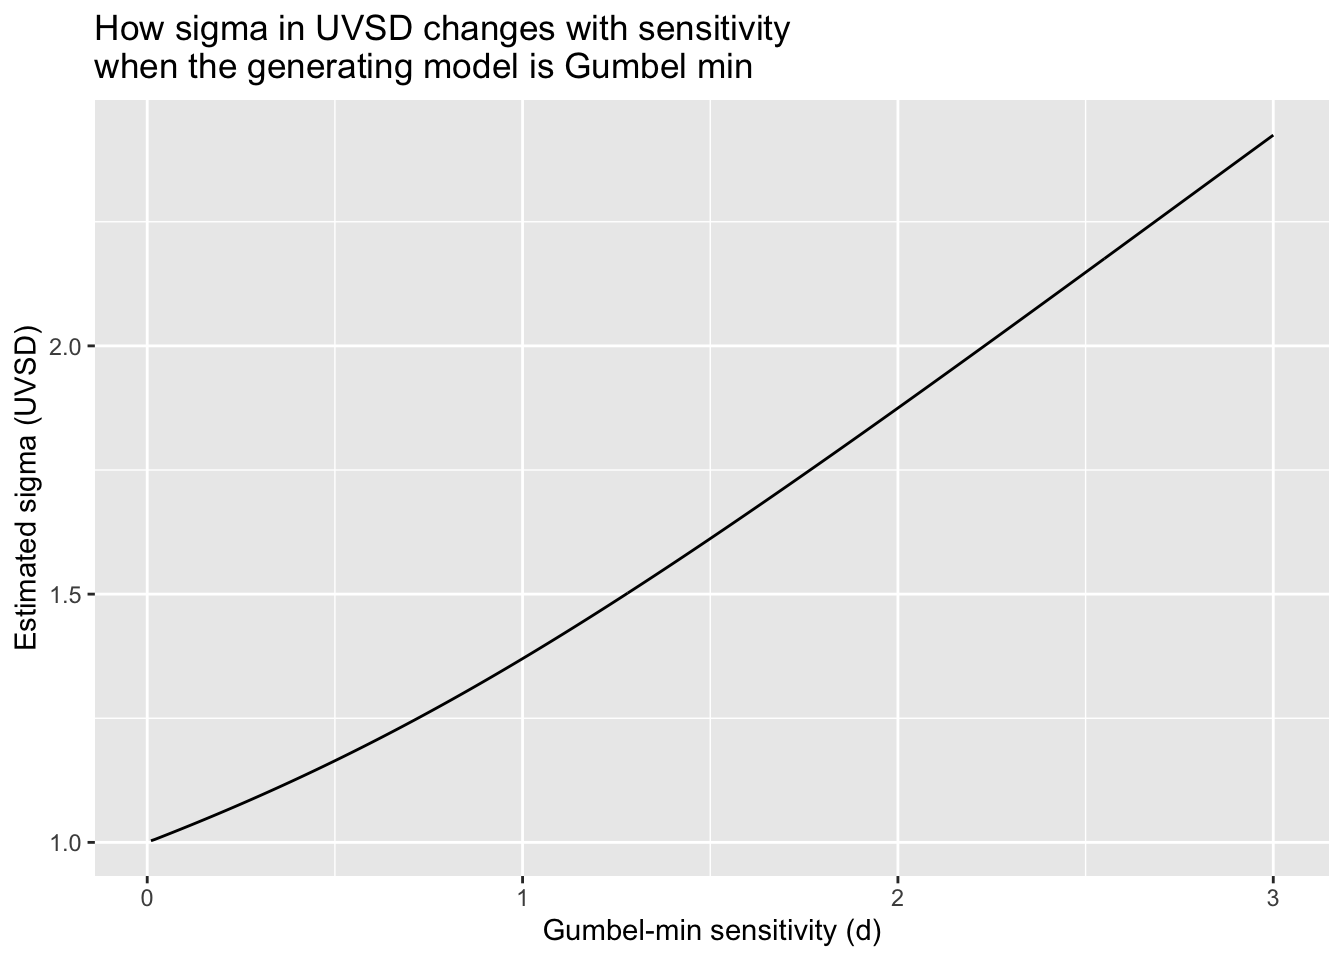

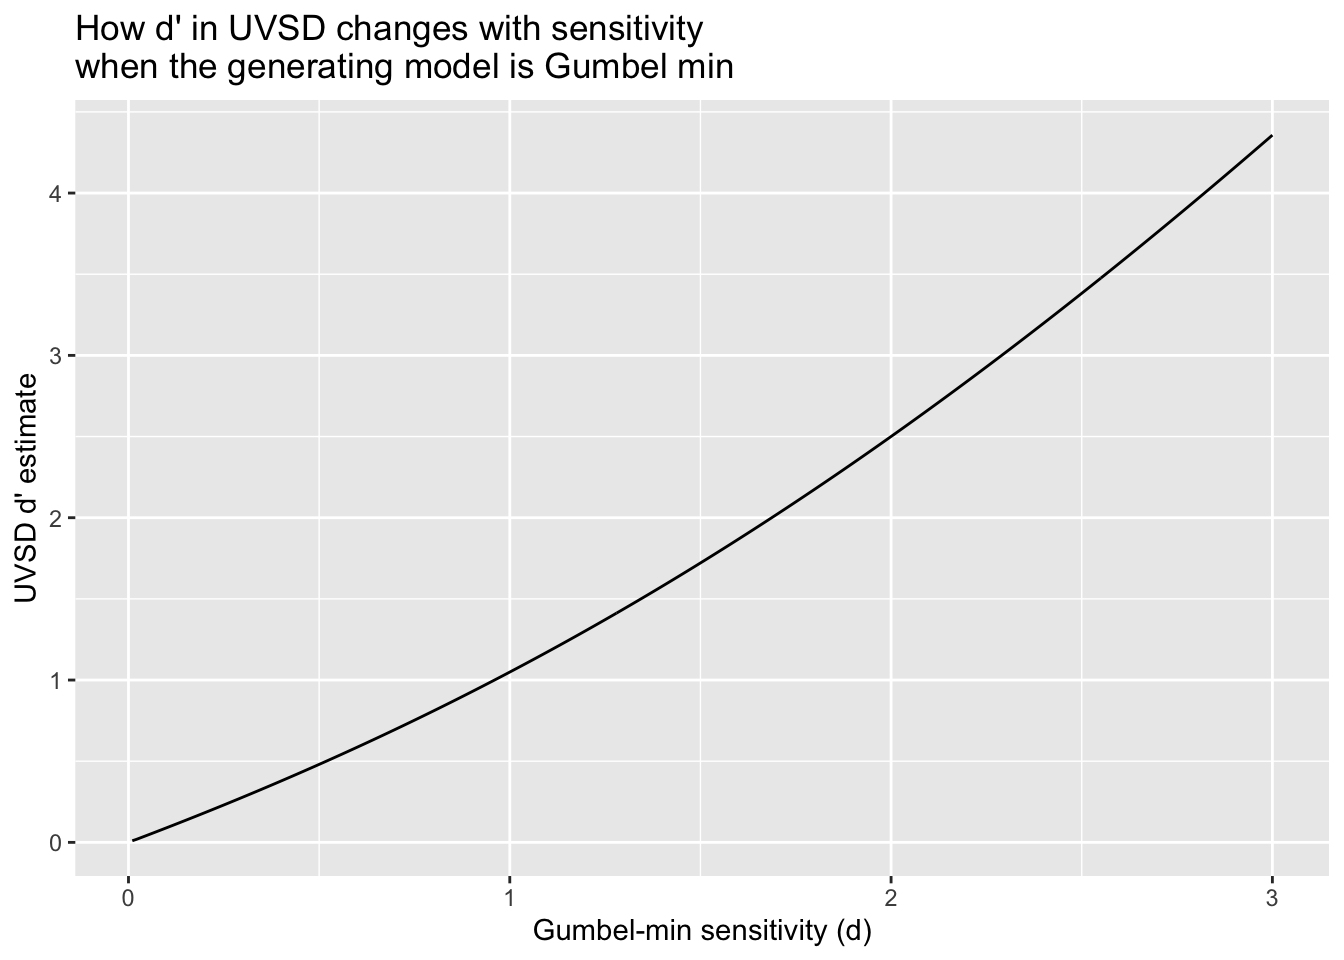

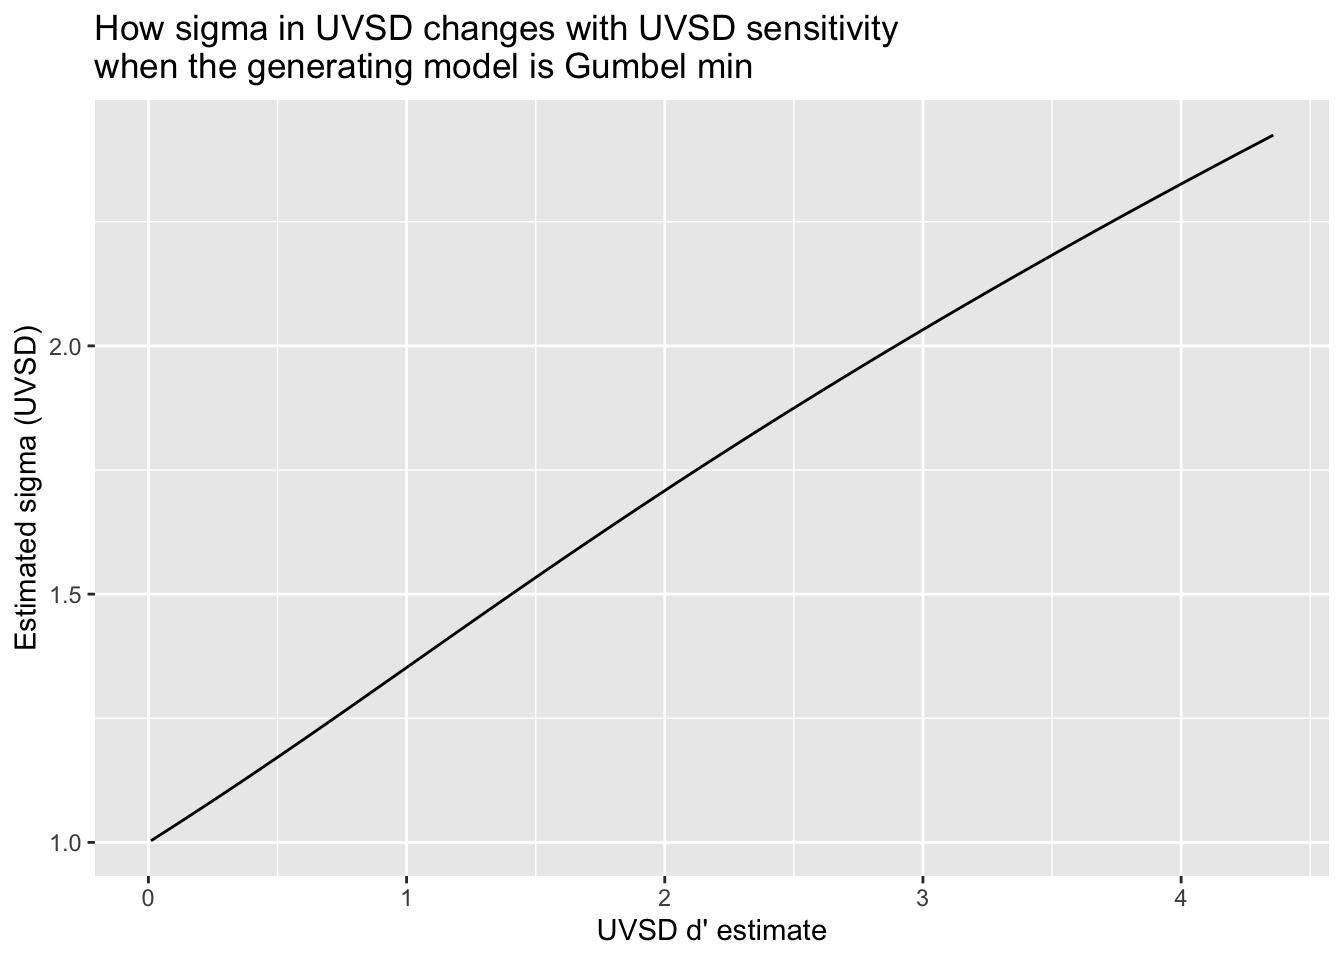

In [ ]:
dat_full <- sim_roc(d_signal = seq(0.01, 3, 0.01), crits = seq(-4, 2, 0.1))

results_full <- do.call(rbind, lapply(split(dat_full, dat_full$cond), function(df) {
  fit <- fit_uvsd(df$hit_rate, df$fa_rate)
  data.frame(cond = df$cond[1], d_est = fit$d, sigma_est = fit$sigma)
}))

ggplot(results_full, aes(x = cond, y = sigma_est)) +
  geom_line() +
  labs(x = "Gumbel-min sensitivity (d)",
       y = "Estimated sigma (UVSD)",
       title = "How sigma in UVSD changes with sensitivity\nwhen the generating model is Gumbel min")
